# Compare RMSE Fourier vs Polynomial over time and space

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load Fourier data
ds_fourier = xr.open_dataset('../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc')
ds_fourier

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

In [4]:
# load Polynomial data
ds_poly = xr.open_dataset('../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc')
ds_poly

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

In [5]:
# subtract RMSE Fourier - Polynomial
rmse_diff = ds_fourier.SummerRMSE - ds_poly.SummerRMSE

In [6]:
# plot each: mean over time as maps
mean_rmse_fourier = ds_fourier.SummerRMSE.mean(dim='time')
mean_rmse_poly = ds_poly.SummerRMSE.mean(dim='time')
mean_rmse_diff = rmse_diff.mean(dim='time')


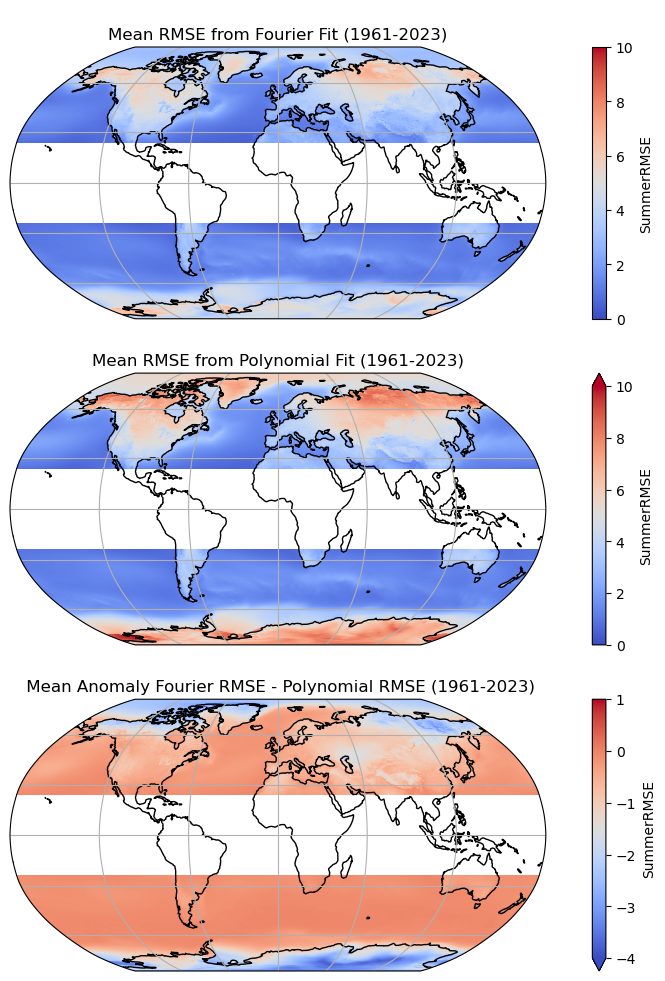

CPU times: user 28.7 s, sys: 270 ms, total: 29 s
Wall time: 29 s


In [14]:
%%time

# takes XX sec

# create blank fig
fig = plt.figure(figsize = (12,12))

# Baseline
ax1 = fig.add_subplot(3,1,1,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax1.coastlines()
ax1.gridlines()

# plot data and exclude tropics
mean_rmse_fourier.where((mean_rmse_fourier.lat > 23.5) | (mean_rmse_fourier.lat < -23.5)).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), 
    vmin=0,
    vmax=10, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)
ax1.set_title("\nMean RMSE from Fourier Fit (1961-2023)")

# Analysis
ax2 = fig.add_subplot(3,1,2,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax2.coastlines()
ax2.gridlines()

mean_rmse_poly.where((mean_rmse_poly.lat > 23.5) | (mean_rmse_poly.lat < -23.5)).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=0,
    vmax=10,  
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)
ax2.set_title("\nMean RMSE from Polynomial Fit (1961-2023)")

# Anomaly
ax3 = fig.add_subplot(3,1,3,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax3.coastlines()
ax3.gridlines()

# set limits based on variable

(mean_rmse_diff).where((mean_rmse_diff.lat > 23.5) | (mean_rmse_diff.lat < -23.5)).plot(
    ax=ax3,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-4.0,
    vmax=1.0, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)
ax3.set_title("\n Mean Anomaly Fourier RMSE - Polynomial RMSE (1961-2023)")

plt.show()